In [3]:
import matplotlib.pyplot as plt

In [11]:
A_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
A_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

len(A_length), len(A_weight)

(35, 35)

In [12]:
B_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
B_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

len(B_length), len(B_weight)

(14, 14)

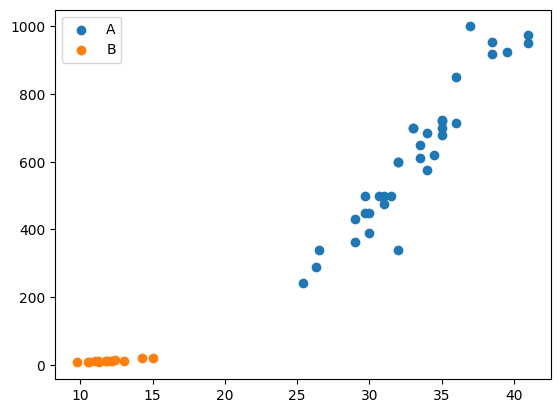

In [9]:
plt.scatter(A_length, A_weight, label='A')
plt.scatter(B_length, B_weight, label='B')
plt.legend()

plt.show()

In [14]:
# 데이터를 합친 다음, 클래스를 분류하는 모델을 만들어보자.
length = A_length + B_length
weight = A_weight + B_weight

X = [[a,b] for a,b in zip(length, weight)]
y = [1]*len(A_length) + [0]*len(B_length)

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X,y)
knn.score(X, y)


1.0

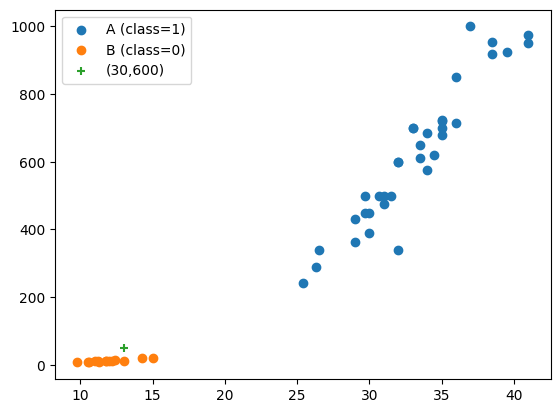

In [35]:
# (30,600)이 어느 그룹에 속하는지 예측하기
plt.scatter(A_length, A_weight, label='A (class=1)')
plt.scatter(B_length, B_weight, label='B (class=0)')
plt.scatter(13,50,label='(30,600)',marker='+')
plt.legend()

plt.show()

In [37]:
# 학습 데이터의 shape과 예측할 데이터의 shape이 일치해야 한다!!!!!
knn.predict([[13,50]]) #다수결로 판단해버림

array([1])

In [38]:
knn = KNeighborsClassifier(n_neighbors=len(X))
knn.fit(X,y)
knn.score(X,y)

0.7142857142857143

In [39]:
len(A_length) / len(X)

0.7142857142857143

In [53]:
# 데이터 분할하기(7:3)
split_num = int(len(X)*0.8)

X_train, y_train = X[:split_num], y[:split_num]
X_test, y_test = X[split_num:], y[split_num:]

In [54]:
knn = KNeighborsClassifier(5)

knn.fit(X_train,y_train)

print(knn.score(X_train,y_train))
print(knn.score(X_test,y_test))

# 과적합!!!
# 학습용 데이터에 문제가 있다. -> class=1에 쏠려있음. class=0에 대해 학습하지 못함. 
# 학습할 때 '학습 데이터'가 잘 섞여 있어야함 .!!

1.0
1.0


In [56]:
import numpy as np
np.unique(y_train,return_counts=True)

(array([0, 1]), array([ 4, 35]))

In [59]:
# 데이터 섞기
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42, stratify=y) #stratify -> class 불균형일 때, class 비율을 유지하며 섞어줌

knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
knn.score(X_train,y_train), knn.score(X_test,y_test)

(1.0, 1.0)

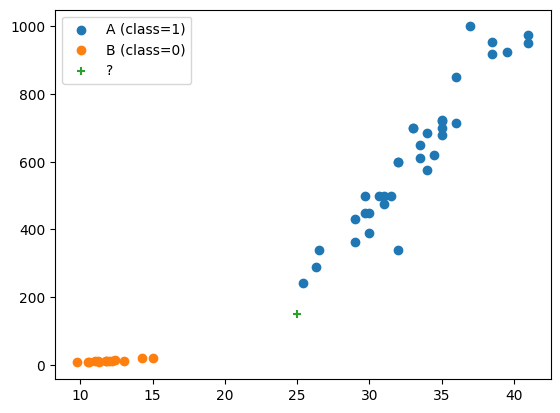

[0]


In [65]:
plt.scatter(A_length, A_weight, label='A (class=1)')
plt.scatter(B_length, B_weight, label='B (class=0)')
plt.scatter(25,150,label='?',marker='+') #1에 가까움
plt.legend()

plt.show()
print(knn.predict([[25,150]])) #0
# 모델이 잘못되었다.. 

In [75]:
distances, indexs = knn.kneighbors([[25,150]])

In [73]:
knn.kneighbors([[25,150]])

(array([[ 92.00086956, 130.48375378, 130.73859415, 138.32150953,
         138.39320793]]),
 array([[21, 33, 19, 30,  1]]))

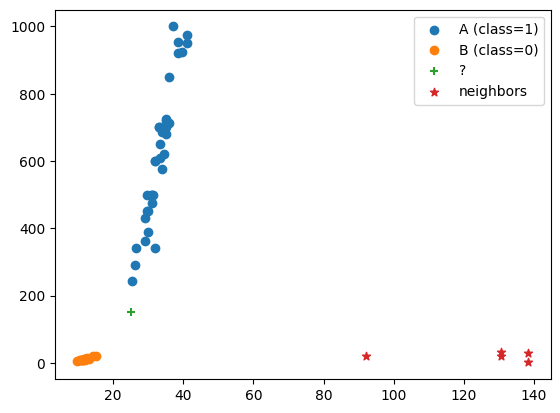

[0]


In [ ]:
plt.scatter(A_length, A_weight, label='A (class=1)')
plt.scatter(B_length, B_weight, label='B (class=0)')
plt.scatter(25,150,label='?',marker='+') #1에 가까움
plt.scatter(,label='neighbors',marker='*')
plt.legend()

plt.show()
print(knn.predict([[25,150]])) #0
# 모델이 잘못되었다.. 

In [ ]:
# 데이터 섞기
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test =  train_test_split(X,y,random_state=42,stratify=y)
# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
knn.predict([[25,150]])

In [ ]:
# np.array(X_train)
np.array(y_train) == 1

In [ ]:
predicted_points = scaler.transform([[25,150]])
predicted_points[:,0][0]

In [ ]:
_, indexs = knn.kneighbors(predicted_points)

In [ ]:
plt.scatter(X_train_scaled[np.array(y_train) == 1,0], 
            X_train_scaled[np.array(y_train)==1,1] )

plt.scatter(X_train_scaled[np.array(y_train) == 0,0], 
            X_train_scaled[np.array(y_train)==0,1] )
plt.scatter(X_train_scaled[indexs,0],X_train_scaled[indexs,1])
plt.scatter(predicted_points[:,0],predicted_points[:,1])

In [ ]:
# Pipe Line
from sklearn.pipeline import Pipeline
pipe = Pipeline([    
    ( 'scale',StandardScaler() ),
    ( 'cls',KNeighborsClassifier() )
])

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y,test_size=0.2)
pipe.fit(X_train,y_train)
pipe.predict([[25,150]])

In [ ]:

# 딥러닝 : 클래스(nn.Module)   nn.Sequential 조립
import torch
import torch.nn as nn

In [ ]:
model = nn.Sequential(
    nn.Linear( 2, 8 ),
    nn.ReLU(),
    nn.Linear( 8, 4 ),
    nn.ReLU(),
    nn.Linear( 4, 2 )  # output        
)
# 입력데이터를 텐서로 변경
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)
X_train,X_test,y_train,y_test \
    = train_test_split(X_tensor,y_tensor,random_state=42,stratify=y,test_size=0.2)

In [ ]:
import torch
import torch.optim as optim

model = nn.Sequential(
    nn.Linear( 2, 8 ),
    nn.ReLU(),
    nn.Linear( 8, 4 ),
    nn.ReLU(),
    nn.Linear( 4, 2 )  # output        
)

# 하이퍼 파라메터
device =  "cuda" if torch.cuda.is_available() else 'cpu'
lr = 1e-03
epochs = 20
model.to(device)


# 손실함수 / 옵티마이져
criterian = nn.CrossEntropyLoss()  # softmax + log 
optim = optim.Adam(model.parameters() , lr=lr)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype = torch.long)

# batch = full dataset
for epoch in range(epochs):
    optim.zero_grad()    
    X_train, y_train = X_train.to(device), y_train.to(device)
    preds = model(X_train)    
    loss = criterian(preds,y_train)
    loss.backward()
    optim.step()

    # # if (epoch+1) % 
    # # 정확도 계산
    yhat = torch.argmax(preds,dim=1)
    acc = (yhat == y_train).float().mean()
    print(f'epoch : {epoch+1}  acc: {acc.item()}')

In [ ]:
import torch
import torch.nn.functional as F

# simoid softamx
# class_1, class_2, class_3
output = torch.tensor([3.0, 1.0, 0.1])

# sigmoid : 개별적으로 적용(0 ~ 1)  각 요소가 독립적이여서 여러개가 정답일수
print(F.sigmoid(output), sum(F.sigmoid(output)))

# softmax  전체의 합이 1   - 서로 경쟁하는 구조
print(F.softmax(output), sum(F.softmax(output)))